# Step 5 — Climate Projection Panel (LOCA2)

**Objective:** Project future extreme heat for ERCOT and CAISO under SSP2-4.5 and SSP5-8.5 using USGS CMIP6-LOCA2 county summaries (27 GCMs, 1950-2100).

**Data source:** https://data.usgs.gov/datacatalog/data/USGS:673d0719d34e6b795de6b593

**Output:** `data/processed/loca2_projections_ercot.csv` and `loca2_projections_caiso.csv`

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from config.settings import PROCESSED, ERCOT_FIPS, CAISO_FIPS, PROJ_PERIODS, SSP_SCENARIOS
from src.data.loca2 import (
    load_loca2, compute_climatology, compute_change_factors,
    build_ercot_projections, build_caiso_projections, LOCA2_VARIABLES
)
from src.viz.maps import projection_bar


## 5.1 Available LOCA2 Climdex variables

In [2]:
for var, desc in LOCA2_VARIABLES.items():
    print(f'  {var:10s}: {desc}')


  SU        : Summer days — annual count of days with Tmax > 25 °C
  TR        : Tropical nights — annual count of days with Tmin > 20 °C
  TXx       : Hottest day of the year (max Tmax, °C)
  WSDI      : Warm Spell Duration Index — max consecutive days Tmax > 90th percentile
  TXge90F   : Days with Tmax ≥ 90 °F
  TXge100F  : Days with Tmax ≥ 100 °F
  Rx1day    : Max 1-day precipitation (mm)
  Rx5day    : Max 5-day precipitation (mm)
  CDD       : Consecutive Dry Days — max run of days with precip < 1 mm
  R20mm     : Annual count of very-heavy rain days (precip ≥ 20 mm)


## 5.2 Build ERCOT projection panel

In [3]:
try:
    ercot_proj = build_ercot_projections()
    print(f'ERCOT projections shape: {ercot_proj.shape}')
    print(ercot_proj.head())
except (FileNotFoundError, RuntimeError) as e:
    print(f'LOCA2 data not yet downloaded:\n{e}')
    ercot_proj = None


Skipping ssp245: No tabular LOCA2 files for 'ssp245' in /burg-archive/home/mck2199/electric-grid-resilience/data/raw/loca2


Skipping ssp585: No tabular LOCA2 files for 'ssp585' in /burg-archive/home/mck2199/electric-grid-resilience/data/raw/loca2


No raw LOCA2 data found — falling back to AR6 regional deltas.


ERCOT projections shape: (532, 39)
    fips scenario period_label  TXx_median  TXx_delta   SU_median  SU_delta  \
0  48001   ssp245         near   41.087143       1.68  229.214286      17.5   
1  48005   ssp245         near   41.037143       1.68  232.071429      17.5   
2  48007   ssp245         near   37.344286       1.68  251.785714      17.5   
3  48013   ssp245         near   43.208571       1.68  275.500000      17.5   
4  48017   ssp245         near   42.480000       1.68  208.928571      17.5   

    TR_median  TR_delta  WSDI_median  ...  TXge90F_p10  TXge90F_p90  \
0  149.428571      21.0    33.714286  ...    92.514286   138.771429   
1  153.428571      21.0    32.571429  ...    88.057143   132.085714   
2  218.142857      21.0    31.714286  ...    74.342857   111.514286   
3  172.857143      21.0    35.000000  ...   128.971429   193.457143   
4   32.142857      21.0    29.142857  ...    89.885714   134.828571   

   TXge100F_p10  TXge100F_p90    CDD_p10    CDD_p90  Rx1day_p10

## 5.3 Build CAISO projection panel

In [4]:
try:
    caiso_proj = build_caiso_projections()
    print(f'CAISO projections shape: {caiso_proj.shape}')
except (FileNotFoundError, RuntimeError) as e:
    print(f'LOCA2 data not yet downloaded:\n{e}')
    caiso_proj = None


Skipping ssp245: No tabular LOCA2 files for 'ssp245' in /burg-archive/home/mck2199/electric-grid-resilience/data/raw/loca2


Skipping ssp585: No tabular LOCA2 files for 'ssp585' in /burg-archive/home/mck2199/electric-grid-resilience/data/raw/loca2


No raw LOCA2 data found — falling back to AR6 regional deltas.


CAISO projections shape: (200, 39)


## 5.4 Key results: additional summer days and heatwave duration by 2050

In [5]:
if ercot_proj is not None:
    mid_ssp585 = ercot_proj[
        (ercot_proj['scenario'] == 'ssp585') &
        (ercot_proj['period_label'] == 'mid')
    ]
    for metric in ['SU_delta', 'WSDI_delta', 'TR_delta', 'TXx_delta']:
        if metric in mid_ssp585.columns:
            print(f'\n{metric} (SSP5-8.5, mid-century):')
            print(mid_ssp585[metric].describe())



SU_delta (SSP5-8.5, mid-century):
count    133.0
mean      40.0
std        0.0
min       40.0
25%       40.0
50%       40.0
75%       40.0
max       40.0
Name: SU_delta, dtype: float64

WSDI_delta (SSP5-8.5, mid-century):
count    133.0
mean      55.0
std        0.0
min       55.0
25%       55.0
50%       55.0
75%       55.0
max       55.0
Name: WSDI_delta, dtype: float64

TR_delta (SSP5-8.5, mid-century):
count    133.0
mean      45.0
std        0.0
min       45.0
25%       45.0
50%       45.0
75%       45.0
max       45.0
Name: TR_delta, dtype: float64

TXx_delta (SSP5-8.5, mid-century):
count    133.0
mean       3.5
std        0.0
min        3.5
25%        3.5
50%        3.5
75%        3.5
max        3.5
Name: TXx_delta, dtype: float64


## 5.5 Visualise projected WSDI change across ERCOT counties

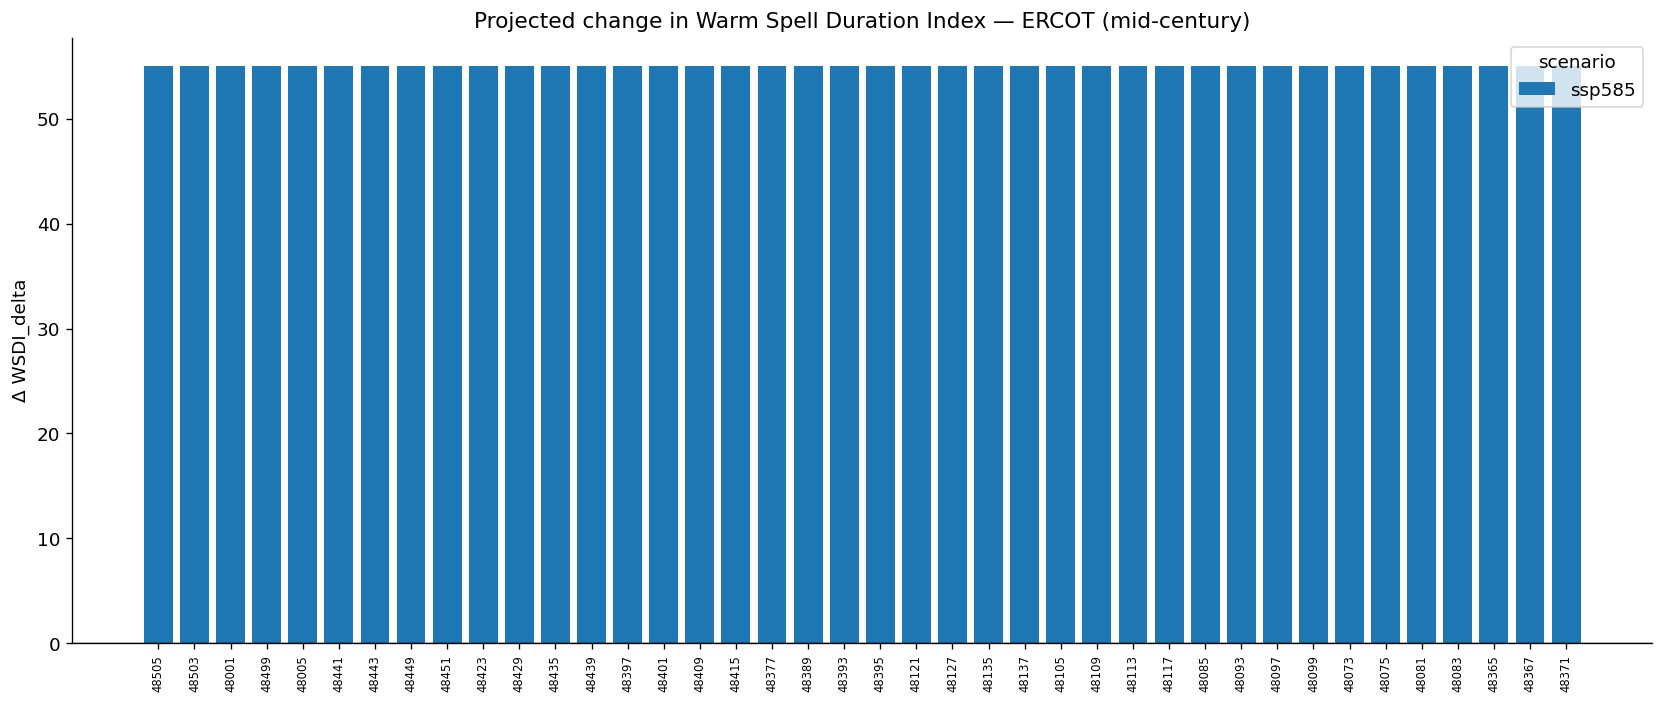

In [6]:
if ercot_proj is not None and 'WSDI_delta' in ercot_proj.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    projection_bar(
        ercot_proj[ercot_proj['period_label'] == 'mid'],
        metric_delta='WSDI_delta',
        title='Projected change in Warm Spell Duration Index — ERCOT (mid-century)',
        ax=ax,
    )
    plt.tight_layout()
    plt.savefig('../data/processed/ercot_wsdi_delta.png', dpi=150)
    plt.show()


## 5.6 Save projection panels

In [7]:
if ercot_proj is not None:
    ercot_proj.to_csv(PROCESSED['loca2_ercot'], index=False)
    print('Saved:', PROCESSED['loca2_ercot'])
if caiso_proj is not None:
    caiso_proj.to_csv(PROCESSED['loca2_caiso'], index=False)
    print('Saved:', PROCESSED['loca2_caiso'])


Saved: /burg-archive/home/mck2199/electric-grid-resilience/data/processed/loca2_projections_ercot.csv
Saved: /burg-archive/home/mck2199/electric-grid-resilience/data/processed/loca2_projections_caiso.csv
